In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Load, cek structure

In [3]:
data = pd.read_csv("D:/Semester 7 (EVAL PA)/Try Code/data_clean.csv")
data.head()

,Usia Kepala Rumah Tangga,Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga),Luas lahan yang dikelola,Frekuensi Panen per Tahun,Produksi Rata - Rata per Panen (Kwintal/Ha),Harga Jual Rata-Rata Hasil Panen Utama (Rp/kg),Pengeluaran Rata-Rata Benih per Tahun (Rp),Pengeluaran Rata-Rata Pupuk per Tahun (Rp),Pengeluaran Rata-Rata Biaya Perawatan per Tahun (Rp),Pendidikan Terakhir_Diploma,...,Sumber Informasi Pertanian Utama_Tetangga,Apakah mempunyai pekerjaan sampingan?_Tidak,Apakah mempunyai pekerjaan sampingan?_Ya,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Tidak,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Ya,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Kurang Subur,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Sedang,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Subur,Apakah pola tanam berubah akibat iklim?_Tidak,Apakah pola tanam berubah akibat iklim?_Ya
0,1.000,1.0,0.276289,0.000000,0.591290,0.051846,0.130094,0.367970,0.244595,False,...,False,False,True,True,False,False,False,True,False,True
1,0.600,0.4,0.608247,1.000000,0.077052,0.483760,0.812289,0.323566,0.746249,False,...,False,True,False,True,False,False,False,True,True,False
2,0.100,0.2,0.538144,0.666667,0.993300,0.919710,0.963582,0.546006,0.893245,False,...,False,True,False,False,True,False,True,False,False,True
3,0.375,0.4,0.752577,0.333333,1.000000,0.227960,0.126164,0.078918,0.912646,False,...,True,False,True,False,True,True,False,False,True,False
4,0.525,0.6,0.156701,0.000000,0.872697,0.492435,0.213517,0.629645,0.807840,False,...,False,False,True,True,False,False,False,True,False,True


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 74 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Usia Kepala Rumah Tangga                                           200 non-null    float64
 1   Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga)              200 non-null    float64
 2   Luas lahan yang dikelola                                           200 non-null    float64
 3   Frekuensi Panen per Tahun                                          200 non-null    float64
 4   Produksi Rata - Rata per Panen (Kwintal/Ha)                        200 non-null    float64
 5   Harga Jual Rata-Rata Hasil Panen Utama (Rp/kg)                     200 non-null    float64
 6   Pengeluaran Rata-Rata Benih per Tahun (Rp)                         200 non-null    float64
 7   Pengeluaran Rata-Rata Pupu

In [5]:
data.describe()

,Usia Kepala Rumah Tangga,Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga),Luas lahan yang dikelola,Frekuensi Panen per Tahun,Produksi Rata - Rata per Panen (Kwintal/Ha),Harga Jual Rata-Rata Hasil Panen Utama (Rp/kg),Pengeluaran Rata-Rata Benih per Tahun (Rp),Pengeluaran Rata-Rata Pupuk per Tahun (Rp),Pengeluaran Rata-Rata Biaya Perawatan per Tahun (Rp)
count,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.50000,0.501000,0.538474,0.486667,0.503509,0.519762,0.459532,0.539378,0.526862
std,0.27685,0.336698,0.295545,0.382241,0.282785,0.292827,0.274232,0.275885,0.289954
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.27500,0.200000,0.275258,0.000000,0.261725,0.283387,0.212356,0.322657,0.261520
50%,0.50000,0.600000,0.554639,0.333333,0.521776,0.524511,0.454924,0.531747,0.571747
75%,0.72500,0.800000,0.779381,1.000000,0.739950,0.775822,0.706907,0.794714,0.767413
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data.isnull().sum()

Usia Kepala Rumah Tangga                                            0
Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga)               0
Luas lahan yang dikelola                                            0
Frekuensi Panen per Tahun                                           0
Produksi Rata - Rata per Panen (Kwintal/Ha)                         0
                                                                   ..
Kondisi Tanah Dominan (berdasarkan persepsi petani)_Kurang Subur    0
Kondisi Tanah Dominan (berdasarkan persepsi petani)_Sedang          0
Kondisi Tanah Dominan (berdasarkan persepsi petani)_Subur           0
Apakah pola tanam berubah akibat iklim?_Tidak                       0
Apakah pola tanam berubah akibat iklim?_Ya                          0
Length: 74, dtype: int64

# EDA

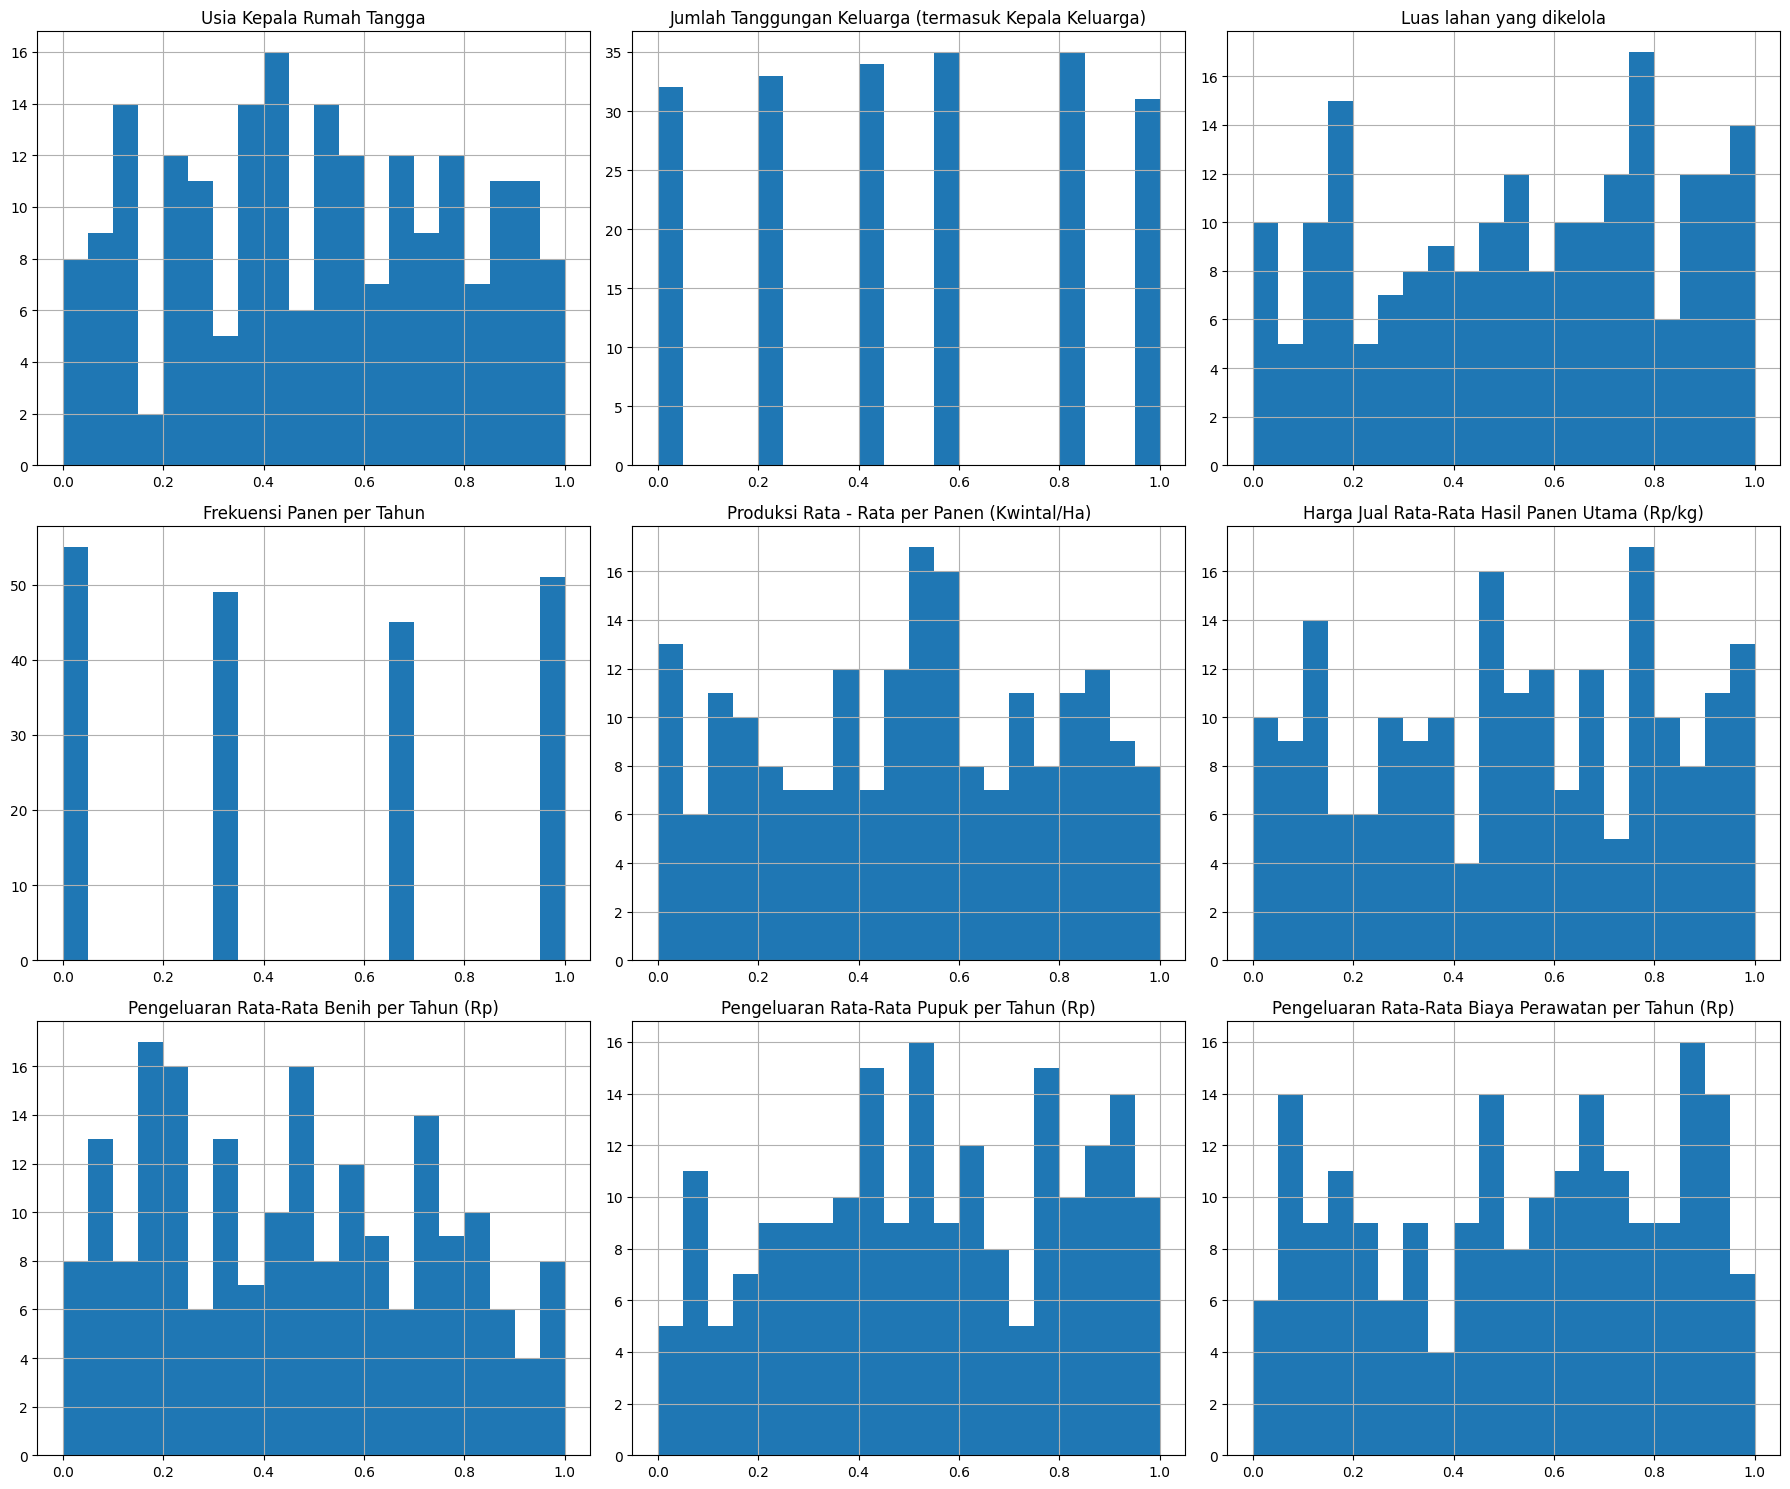

In [7]:
data.hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

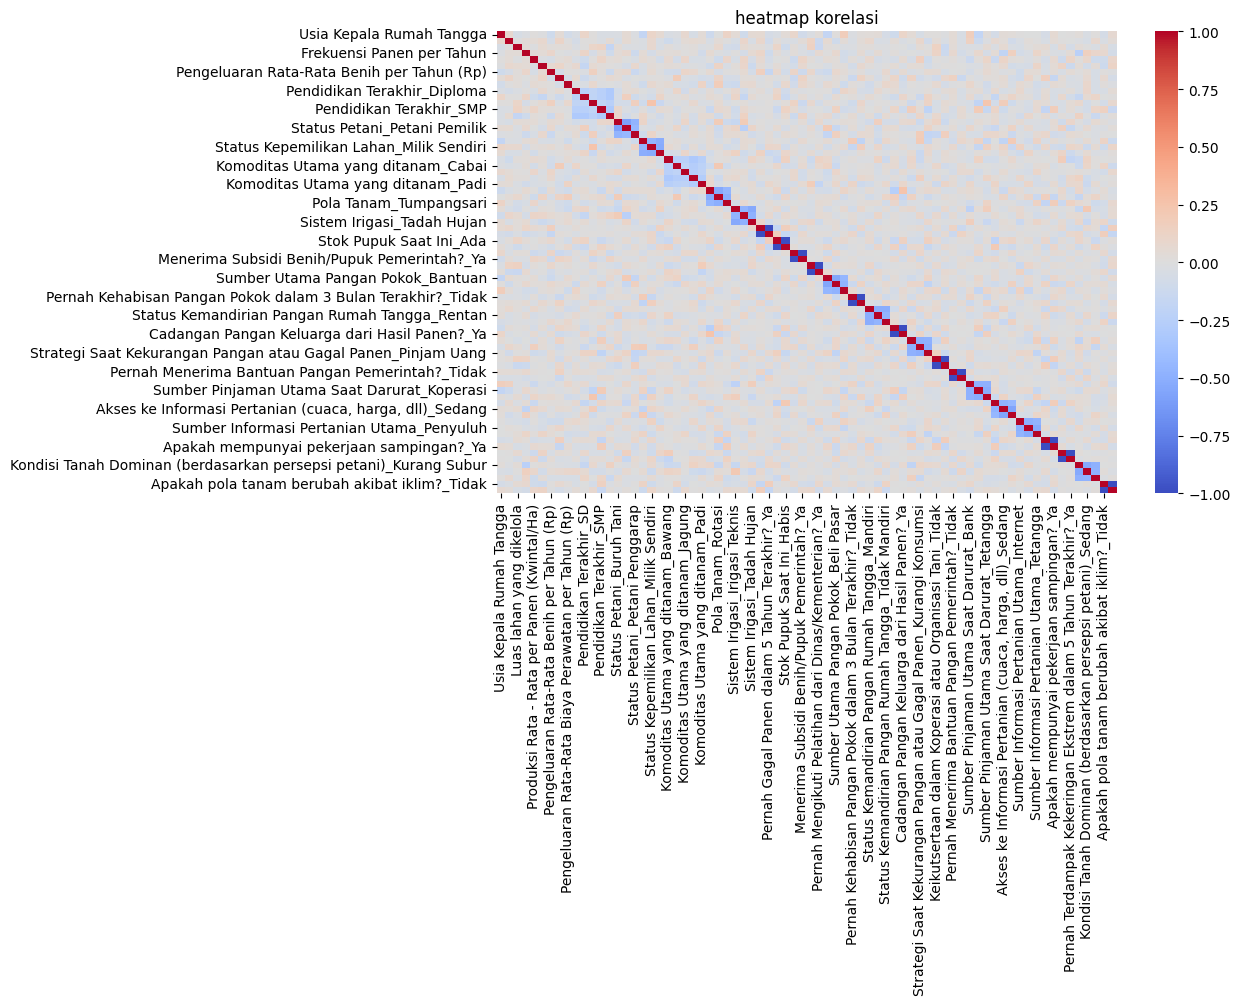

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title('heatmap korelasi')
plt.show()

# detect outlier

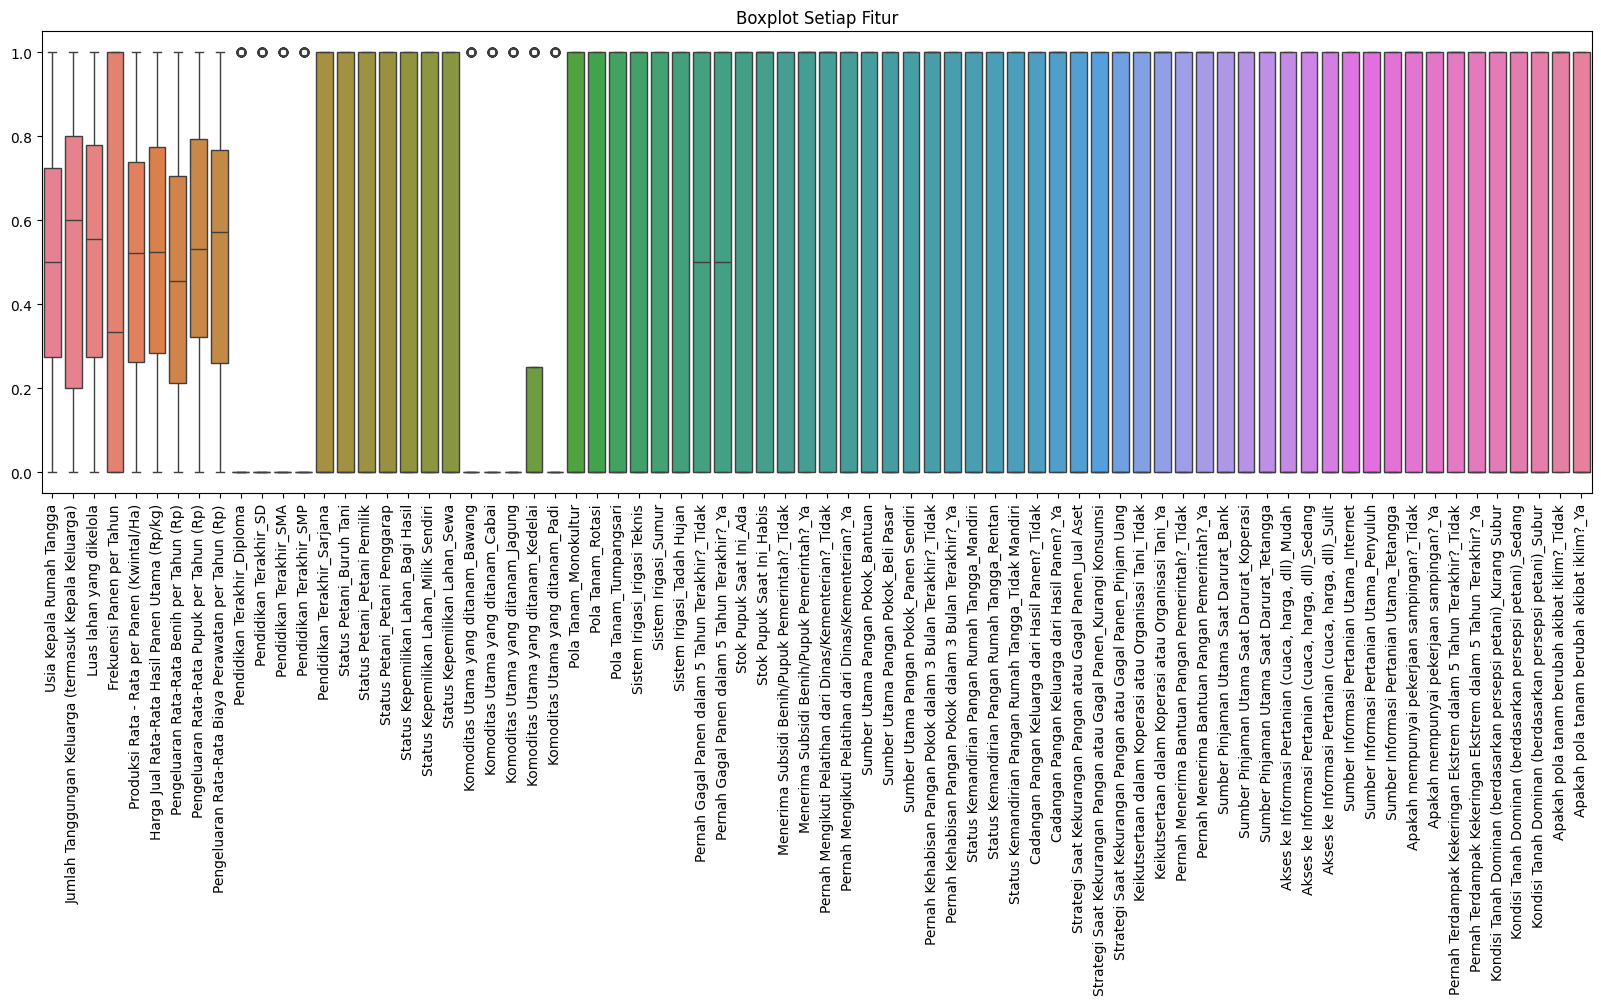

In [9]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title('Boxplot Setiap Fitur')
plt.show()

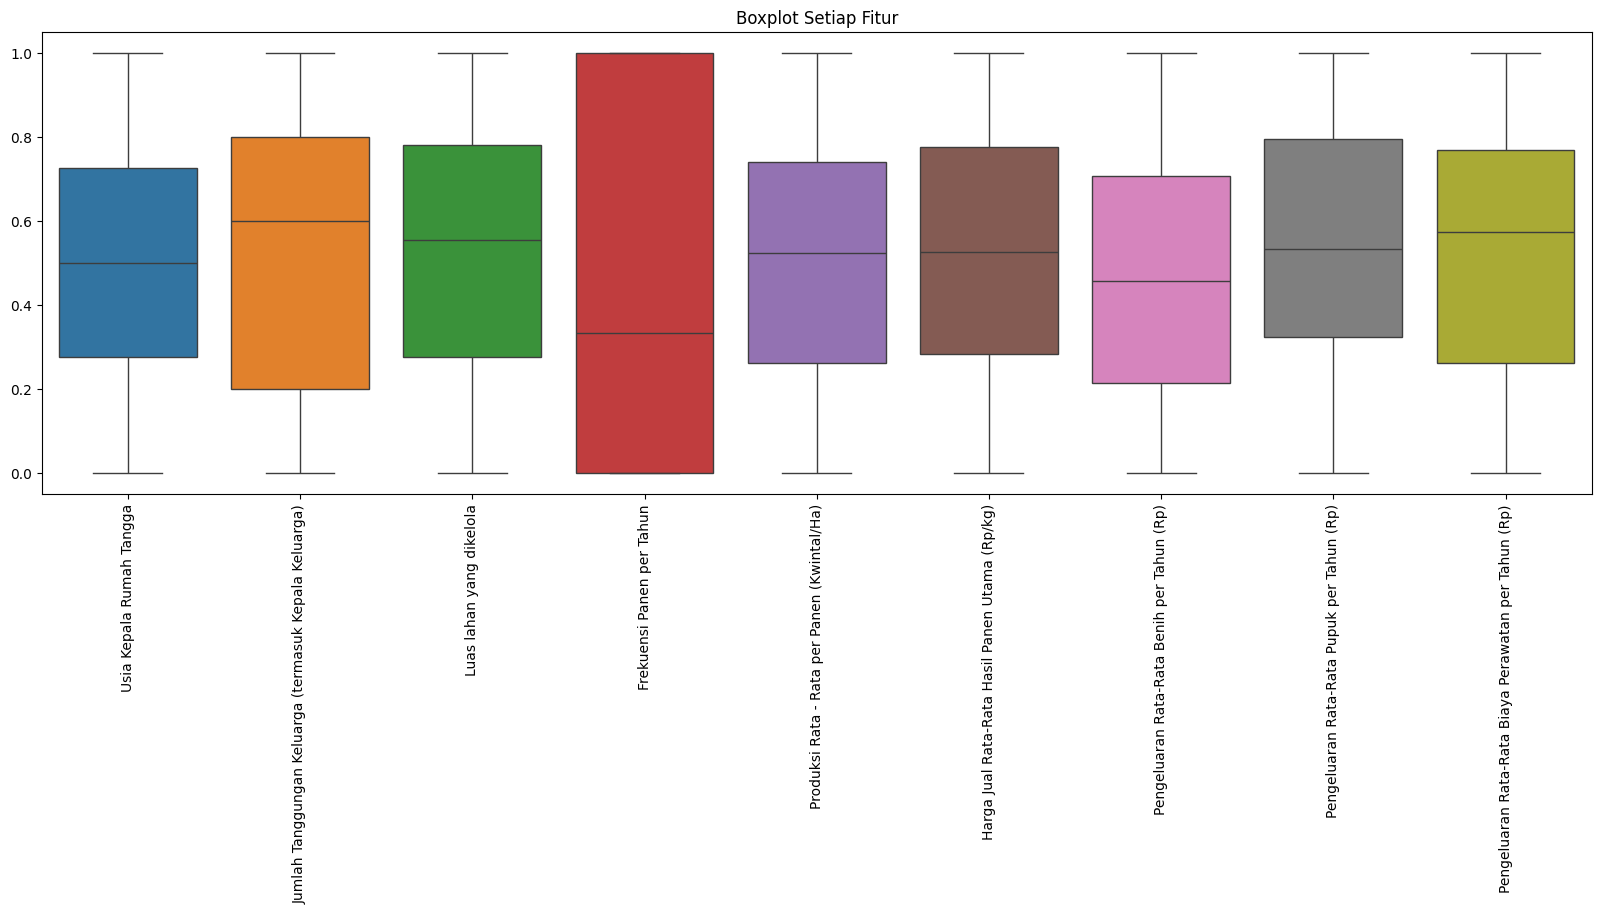

In [10]:
numeric_cols = data.select_dtypes(include=['float64']).columns
plt.figure(figsize=(20, 6))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=90)
plt.title('Boxplot Setiap Fitur')
plt.show()

dari boxplot tersebut terlihat kalo
* fitur paling skewed
1. Jumlah Tanggungan
Kotak panjang, median dekat bawah → positively skewed (banyak yang nilainya kecil, sedikit yang besar).
Banyak outlier di atas.
2. Usia Kepala Rumah Tangga
Hampir normal, tapi ada outlier usia tinggi.
3. Penghasilan (jika ada di data)
Biasanya sangat skewed (sedikit penghasilan tinggi → outlier).
4. Luas Lahan
Skewed ke kanan (banyak lahan kecil, sedikit lahan sangat besar).

* pendidikan, status perumahan, jenis pekerjaan, dll itu tipis banget di 0/1, tapi ini normal untuk data kategorikal

In [11]:
num_bool_cols = data.select_dtypes(include=['float64', 'int64', 'bool']).columns
df_cluster = data[num_bool_cols].copy()
df_cluster = df_cluster.astype(int)
#scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

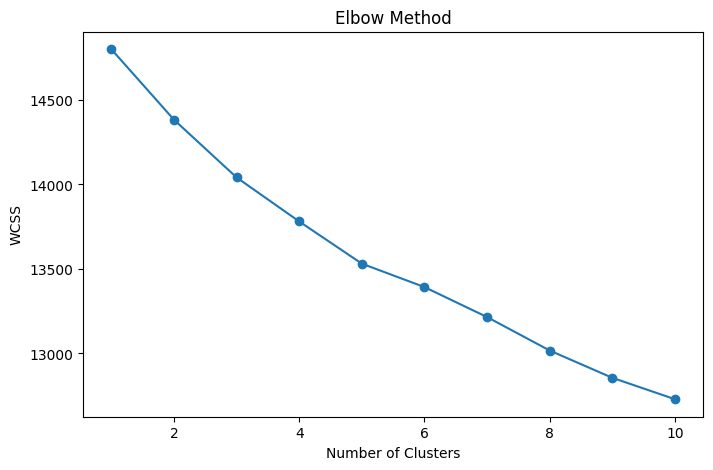

In [12]:
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_data)

In [14]:
data['Cluster'] = df_cluster['Cluster']

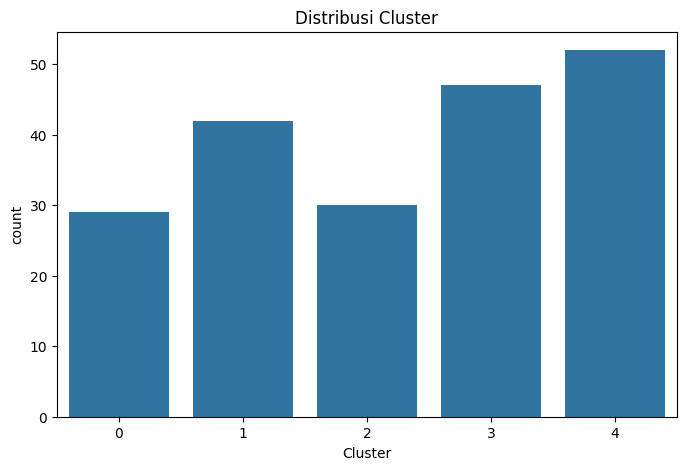

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', data=df_cluster)
plt.title('Distribusi Cluster')
plt.show()

In [28]:
silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
db_index = davies_bouldin_score(scaled_data, kmeans.labels_)

print("=== Evaluasi K-Means ===")
print(f"Silhouette Score       : {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index   : {db_index:.4f}")

=== Evaluasi K-Means ===
Silhouette Score       : 0.0163
Davies-Bouldin Index   : 4.3078


In [24]:
optics = OPTICS(min_samples=5, xi=0.01, min_cluster_size=0.03)
optics_labels = optics.fit_predict(scaled_data)
df_cluster['OPTICS_Cluster'] = optics_labels
data['OPTICS_Cluster'] = optics_labels

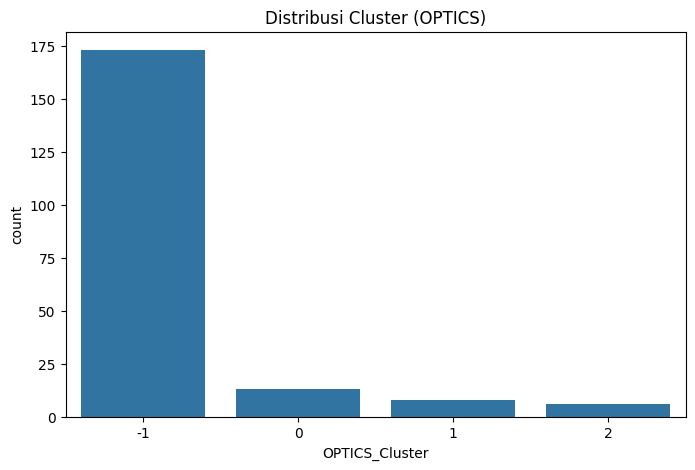

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x='OPTICS_Cluster', data=df_cluster)
plt.title('Distribusi Cluster (OPTICS)')
plt.show()

In [26]:
mask = optics_labels != -1
if len(set(optics_labels[mask])) > 1:
    sil_optics = silhouette_score(scaled_data[mask], optics_labels[mask])
    db_optics = davies_bouldin_score(scaled_data[mask], optics_labels[mask])
    print(f"OPTICS Silhouette Score: {sil_optics:.4f}")
    print(f"OPTICS Davies-Bouldin Score: {db_optics:.4f}")
else:
    print("OPTICS menghasilkan hanya 1 cluster (atau banyak noise). Silhouette & DB tidak bisa dihitung.")

OPTICS Silhouette Score: 0.1411
OPTICS Davies-Bouldin Score: 1.8585


In [36]:
print("\n=== Perbandingan ===")
print(f"Silhouette: K-Means={silhouette_avg:.4f}, OPTICS={sil_optics:.4f}")
print(f"Davies-Bouldin: K-Means={db_index:.4f}, OPTICS={db_optics:.4f}")

if sil_optics > silhouette_avg and db_optics < db_index:
    print("➡ OPTICS lebih baik.")
elif silhouette_avg > sil_optics and db_index < db_optics:
    print("➡ K-Means lebih baik.")
else:
    print("➡ Hasil seimbang, pertimbangkan interpretasi & distribusi cluster.")


=== Perbandingan ===
Silhouette: K-Means=0.0163, OPTICS=0.1411
Davies-Bouldin: K-Means=4.3078, OPTICS=1.8585
➡ OPTICS lebih baik.


In [37]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df_cluster['PCA1'] = pca_data[:, 0]
df_cluster['PCA2'] = pca_data[:, 1]

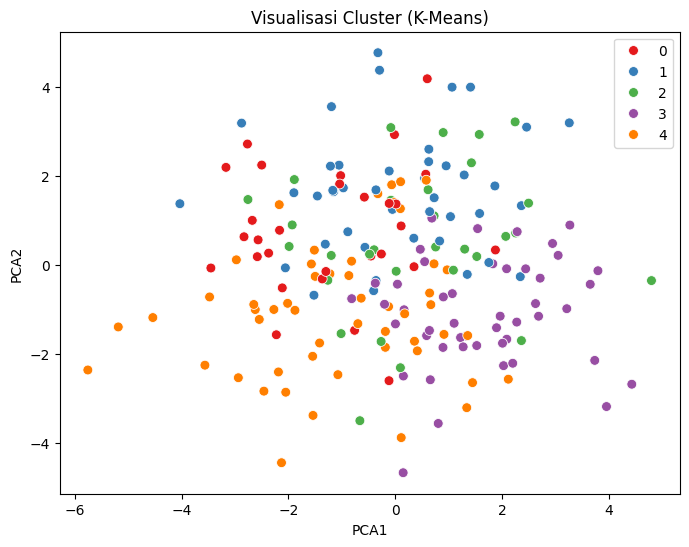

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_cluster, palette='Set1', s=50)
plt.title('Visualisasi Cluster (K-Means)')
plt.legend()
plt.show()

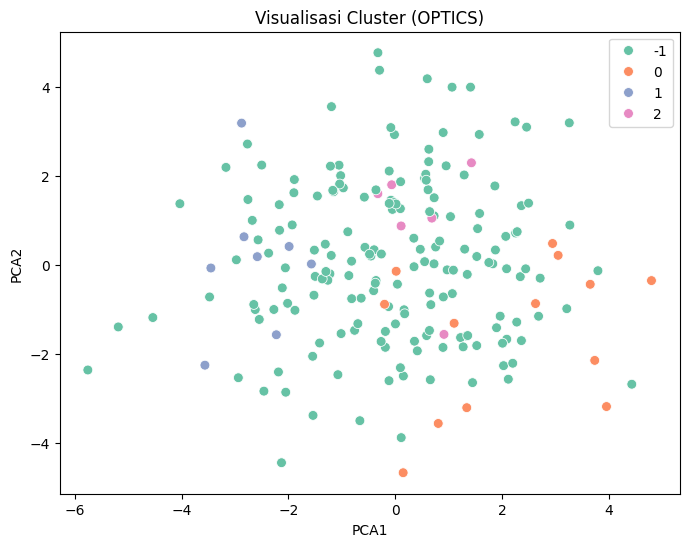

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='OPTICS_Cluster', data=df_cluster, palette='Set2', s=50)
plt.title('Visualisasi Cluster (OPTICS)')
plt.legend()
plt.show()

In [41]:
print("\n=== Profiling K-Means ===")
data.groupby('Cluster').mean()


=== Profiling K-Means ===


,Usia Kepala Rumah Tangga,Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga),Luas lahan yang dikelola,Frekuensi Panen per Tahun,Produksi Rata - Rata per Panen (Kwintal/Ha),Harga Jual Rata-Rata Hasil Panen Utama (Rp/kg),Pengeluaran Rata-Rata Benih per Tahun (Rp),Pengeluaran Rata-Rata Pupuk per Tahun (Rp),Pengeluaran Rata-Rata Biaya Perawatan per Tahun (Rp),Pendidikan Terakhir_Diploma,...,Apakah mempunyai pekerjaan sampingan?_Tidak,Apakah mempunyai pekerjaan sampingan?_Ya,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Tidak,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Ya,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Kurang Subur,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Sedang,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Subur,Apakah pola tanam berubah akibat iklim?_Tidak,Apakah pola tanam berubah akibat iklim?_Ya,OPTICS_Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.475862,0.420690,0.534376,0.540230,0.492174,0.492150,0.437746,0.652164,0.591772,0.275862,...,0.965517,0.034483,0.275862,0.724138,0.344828,0.482759,0.172414,0.793103,0.206897,-0.620690
1,0.502976,0.514286,0.557977,0.444444,0.514078,0.515414,0.488742,0.540148,0.494856,0.261905,...,0.833333,0.166667,0.690476,0.309524,0.261905,0.547619,0.190476,0.285714,0.714286,-0.952381
2,0.513333,0.606667,0.552990,0.555556,0.553210,0.558792,0.472071,0.517342,0.611728,0.100000,...,0.500000,0.500000,0.500000,0.500000,0.200000,0.233333,0.566667,0.233333,0.766667,-0.766667
3,0.532979,0.489362,0.552665,0.418440,0.482198,0.470283,0.445757,0.540807,0.512606,0.191489,...,0.531915,0.468085,0.723404,0.276596,0.574468,0.212766,0.212766,0.595745,0.404255,-0.723404
4,0.473558,0.484615,0.503807,0.512821,0.491882,0.560877,0.453304,0.487278,0.480439,0.153846,...,0.134615,0.865385,0.423077,0.576923,0.307692,0.288462,0.403846,0.596154,0.403846,-0.730769


In [42]:

print("\n=== Profiling OPTICS (tanpa noise) ===")
data[data['OPTICS_Cluster'] != -1].groupby('OPTICS_Cluster').mean()


=== Profiling OPTICS (tanpa noise) ===


,Usia Kepala Rumah Tangga,Jumlah Tanggungan Keluarga (termasuk Kepala Keluarga),Luas lahan yang dikelola,Frekuensi Panen per Tahun,Produksi Rata - Rata per Panen (Kwintal/Ha),Harga Jual Rata-Rata Hasil Panen Utama (Rp/kg),Pengeluaran Rata-Rata Benih per Tahun (Rp),Pengeluaran Rata-Rata Pupuk per Tahun (Rp),Pengeluaran Rata-Rata Biaya Perawatan per Tahun (Rp),Pendidikan Terakhir_Diploma,...,Apakah mempunyai pekerjaan sampingan?_Tidak,Apakah mempunyai pekerjaan sampingan?_Ya,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Tidak,Pernah Terdampak Kekeringan Ekstrem dalam 5 Tahun Terakhir?_Ya,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Kurang Subur,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Sedang,Kondisi Tanah Dominan (berdasarkan persepsi petani)_Subur,Apakah pola tanam berubah akibat iklim?_Tidak,Apakah pola tanam berubah akibat iklim?_Ya,Cluster
OPTICS_Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.400000,0.538462,0.616336,0.256410,0.468754,0.538974,0.480957,0.613355,0.532059,0.153846,...,0.538462,0.461538,0.846154,0.153846,0.769231,0.076923,0.153846,0.384615,0.615385,2.923077
1,0.534375,0.375000,0.639948,0.583333,0.438023,0.527360,0.416428,0.534768,0.490956,0.250000,...,0.750000,0.250000,0.250000,0.750000,0.000000,0.250000,0.750000,0.750000,0.250000,1.375000
2,0.433333,0.333333,0.340206,0.611111,0.501117,0.647905,0.596421,0.558026,0.386049,0.333333,...,0.833333,0.166667,0.166667,0.833333,0.333333,0.666667,0.000000,0.166667,0.833333,2.833333
